In [18]:
# Presentation:
# - Multi-Object

<unknown>:29: SyntaxWarning: invalid escape sequence '\s'
<unknown>:52: SyntaxWarning: invalid escape sequence '\d'
<unknown>:258: SyntaxWarning: invalid escape sequence '\e'
<unknown>:269: SyntaxWarning: invalid escape sequence '\s'
<unknown>:29: SyntaxWarning: invalid escape sequence '\s'
<unknown>:52: SyntaxWarning: invalid escape sequence '\d'
<unknown>:308: SyntaxWarning: invalid escape sequence '\e'
<unknown>:319: SyntaxWarning: invalid escape sequence '\s'


In [19]:
# reloads modules before executing
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from classes.particle_filter import ParticleFilter
from classes.particle_filter_multiple import MultiObjectParticleFilter
from classes.observation import TransitionModel, ObservationModel
from classes.simulator import create_ground_truth, generate_random_balls, create_ground_truth_n_balls
from classes.plotting import plot_sim_n_balls_point_prediction, plot_particles_at_time, animate_particle_filter, plot_particle_filter_step
from classes.evaluator import get_stats
from classes.tester import create_test_scenario, ParticleFilterTester, run_one_test
import numpy as np

In [56]:
seed = 5

STATE_BOUNDS = [
    (0.0, 50.0),    # x bounds
    (0.0, 50.0),    # y bounds
    (-30.0, 30.0),  # vx bounds
    (0.0, 40.0)     # vy bounds
]

# Simulation Parameters
dropout_start = 40
dropout_end = 60
process_noise = 2.0#2.0
measurement_noise = 9.0#9.0

# A LOT of balls:
true_states = generate_random_balls(num_balls=3, state_bounds=STATE_BOUNDS)
#true_states = np.array([[50.0, 50.0, 15.0, 25.0], [10.0, 10.0, 12.0, 30.0], [20.0, 20.0, 30.0, 3.0]], dtype=float)
true_states = np.array([[50.0, 50.0, 15.0, 25.0], [50.0, 50.0, -12.0, 30.0], [50.0, 50.0, 30.0, 3.0]], dtype=float)
    
n_objects = len(true_states)

# Particle Filter Parameters
num_particles_per_ball = 3000

input_parameters = {
    # Parameters for the simulation
    "step_size": 0.1,
    "num_steps": 40,

    # Parameters for the balls
    "true_states": true_states,
    "dropout_start": 40,
    "dropout_end": 60,
    "process_noise": 2.0,#9.0, # Since we copy particles when resampling, process noise spreads them out in an area to make particles more diverse.
    "measurement_noise": 9.0,#25.0,

    "change_resample_order": True,

    # Parameters for the Filter
    "model": "SingleParticleFilter", # Either "MultiObjectParticleFilter" or "SingleObjectParticleFilter"

    "num_particles": 1_024*3, # For Multi-Object Particle Filter, this is the number of particles PER BALL
    "state_bounds": STATE_BOUNDS,
    "init_generator": "Sobol", # Either "Sobol", "LHS", or "PseudoRandom"

    'ess_resample_threshold': np.inf, # Always resample

    "logs": ["PF", "GMM"]
}

tester = ParticleFilterTester(input_parameters, save_dir="results")
results = tester.run()
#results
#results = tester.sweep_multi({
    #"use_velocity_likelihood": [True, False],
#}, mode="grid", seed=seed)
#results

Exec ParticleFilter with 9216 Particles and 3 balls. change_resample_order = True
Resampling - Var 1
INIT COVARIANCE
Fitting Model finished after 100 iterations. Delta 0.0
Time Step: 0, Estimated Position: 
[[47.56962847 49.85892457  7.31387227 17.42605652]
 [44.27374142 48.27056498  1.02552839 21.50254785]
 [43.20663899 51.92421502  2.07949172 32.23709071]]
Fitting Model finished after 100 iterations. Delta 0.0
Time Step: 1, Estimated Position: 
[[49.31595503 49.87282712 12.8620977  13.75008573]
 [48.12221824 54.03093654  2.46381821 30.13360762]
 [46.14703821 51.85821742  7.34632767 29.76763676]]
Early Stopping after 66 iterations with delta: 9.538955055177212e-05
Time Step: 2, Estimated Position: 
[[49.64013122 55.38302062 15.67245112 34.49721459]
 [49.13823809 54.36201866 13.33487147 25.00691686]
 [45.16177788 52.99817002 -6.46510955 29.19898219]]
--> Cluster lost. Resampling around Estimation.
Early Stopping after 93 iterations with delta: 8.909441385185346e-05
Time Step: 3, Estima

<unknown>:51: SyntaxWarning: invalid escape sequence '\s'
<unknown>:69: SyntaxWarning: invalid escape sequence '\d'
<unknown>:285: SyntaxWarning: invalid escape sequence '\e'
<unknown>:296: SyntaxWarning: invalid escape sequence '\s'
<unknown>:44: SyntaxWarning: invalid escape sequence '\s'
<unknown>:62: SyntaxWarning: invalid escape sequence '\d'
<unknown>:279: SyntaxWarning: invalid escape sequence '\e'
<unknown>:290: SyntaxWarning: invalid escape sequence '\s'
Failed to reload module 'classes.tester' from file '/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/tester.py'
Traceback (most recent call last):
  File "/usr/local/Caskroom/miniforge/base/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/Caskroom/miniforge/base/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 584, in super

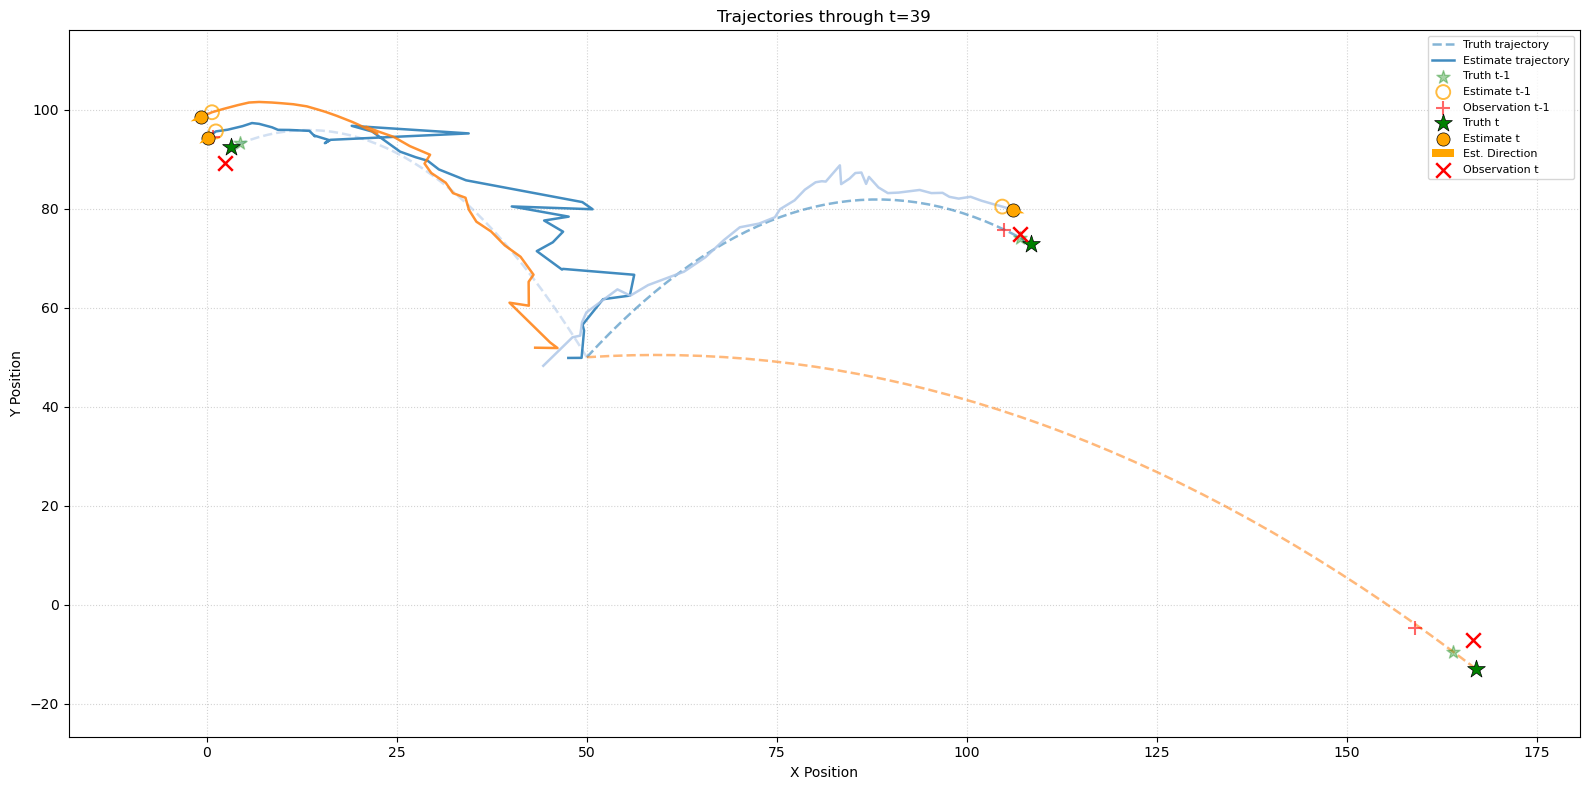

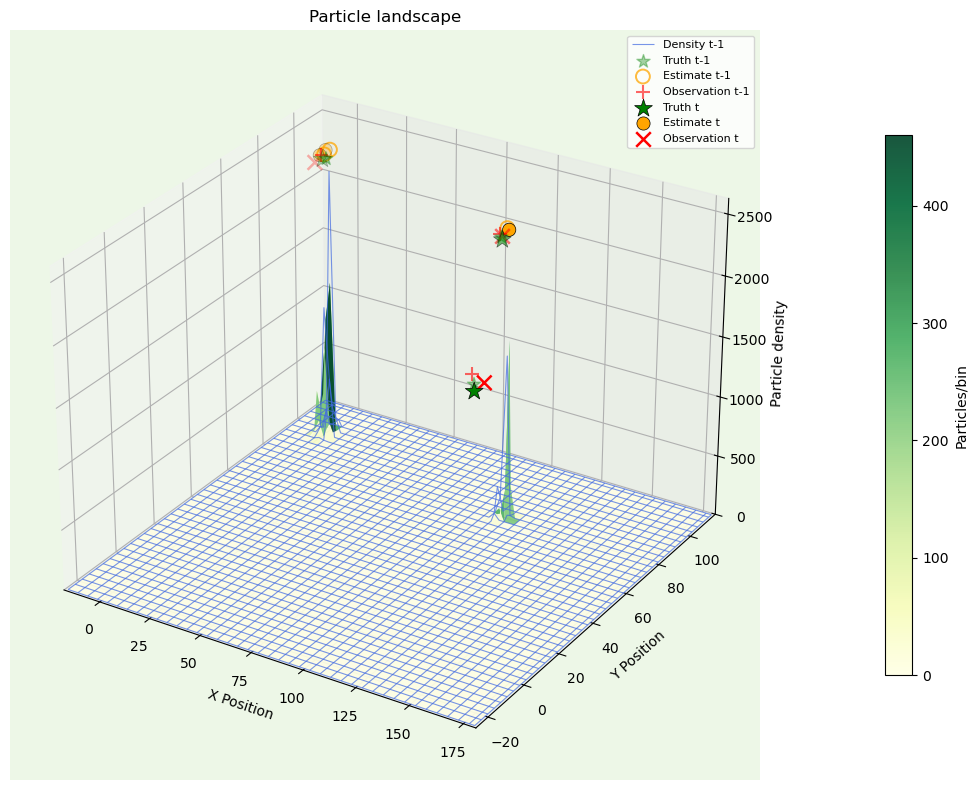

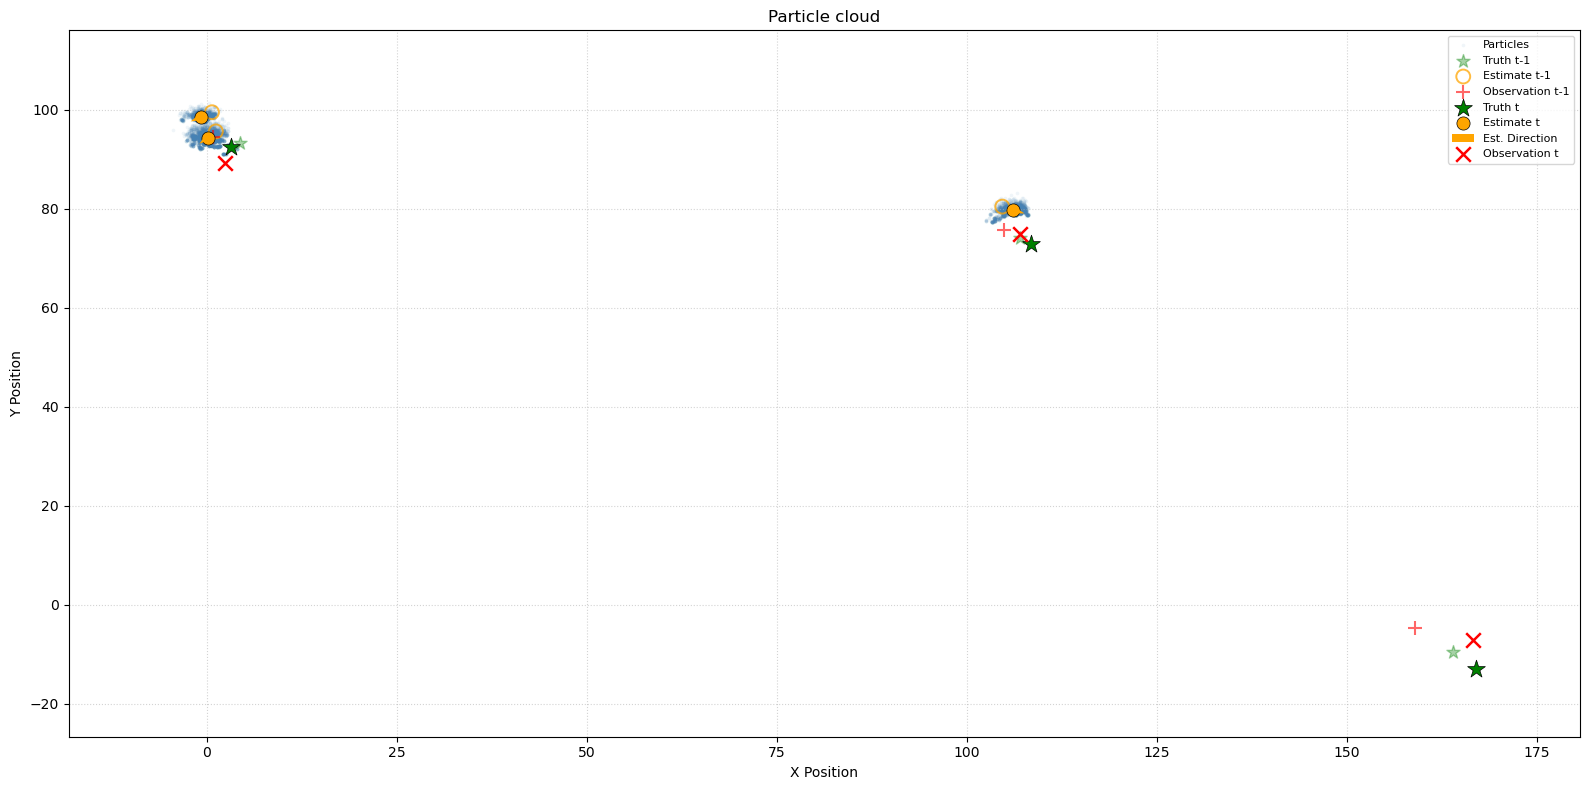

((<Figure size 1600x800 with 1 Axes>,
  <Figure size 1600x800 with 2 Axes>,
  <Figure size 1600x800 with 1 Axes>),
 (<Axes: title={'center': 'Trajectories through t=39'}, xlabel='X Position', ylabel='Y Position'>,
  <Axes3D: title={'center': 'Particle landscape'}, xlabel='X Position', ylabel='Y Position', zlabel='Particle density'>,
  <Axes: title={'center': 'Particle cloud'}, xlabel='X Position', ylabel='Y Position'>))

In [58]:
plot_particle_filter_step(time=39, **results["raw"])